测试数据和训练数据分组，数据分batch

In [1]:
# 加载数据
import torch
from joblib import dump, load
import torch.utils.data as Data
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
# 参数与配置
torch.manual_seed(100)  # 设置随机种子，以使实验结果具有可重复性
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 加载数据集
def dataloader(batch_size, workers=2):
    # 训练集
    train_set = load('../dataresult/train_set')
    train_label = load('../dataresult/train_label')
    # 测试集
    test_set = load('../dataresult/test_set')
    test_label = load('../dataresult/test_label')

    # 加载数据
    train_loader = Data.DataLoader(dataset=Data.TensorDataset(train_set, train_label),
                                   batch_size=batch_size, num_workers=workers, drop_last=True)
    test_loader = Data.DataLoader(dataset=Data.TensorDataset(test_set, test_label),
                                  batch_size=batch_size, num_workers=workers, drop_last=True)
    return train_loader, test_loader

batch_size = 256
# 加载数据
train_loader, test_loader = dataloader(batch_size)

print(len(train_loader))
print(len(test_loader))

14
9


定义自注意力机制


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SelfAttention(nn.Module):
    def __init__(self, embed_dim):
        super(SelfAttention, self).__init__()
        self.embed_dim = embed_dim
        self.query = nn.Linear(embed_dim, embed_dim)
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)
        
    def forward(self, x):
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)
        
        attention_weights = F.softmax(torch.matmul(q, k.transpose(1, 2)) / torch.sqrt(torch.tensor(self.embed_dim)), dim=-1)
        output = torch.matmul(attention_weights, v)
        
        return output

定义 BiGRU-Attention  回归预测网络


In [3]:
# 定义 BiGRUAttention 模型
class BiGRUAttention(nn.Module):
    def __init__(self, input_dim, hidden_layer_sizes, output_dim, attention_dim):
        """
        BiGRUAttention 预测任务  params:
        input_dim        : 输入数据的维度
        hidden_layer_size: 隐层的数目和维度
        output_dim       : 输出维度
        attention_dim     : 自注意力机制维度
        """
        super().__init__()
        # BiGRU参数
        self.num_layers = len(hidden_layer_sizes)  # bigru层数
        self.bigru_layers = nn.ModuleList()  # 用于保存bigru层的列表
        # 定义第一层BiGRU  
        self.bigru_layers.append(nn.GRU(input_dim, hidden_layer_sizes[0], batch_first=True, bidirectional=True))
        # 定义后续的BiGRU  层
        for i in range(1, self.num_layers):
                self.bigru_layers.append(nn.GRU(hidden_layer_sizes[i-1]* 2, hidden_layer_sizes[i], batch_first=True, bidirectional=True))

        # 定义自注意力层
        self.attention = SelfAttention(attention_dim)

        # 自适应平均池化
        self.adaptive_pool = nn.AdaptiveAvgPool1d(1)

        # 定义线性层
        self.linear  = nn.Linear(hidden_layer_sizes[-1] * 2, output_dim)

       
    def forward(self, input_seq): 
        # 前向传播的过程是输入->BiGRU  层->全连接层->输出
        # 在观察查看BiGRU输入的维度，BiGRU的第一个输入input_size维度是(batch, seq_length, dim) batch是batch size , seq_length是序列长度，dim是输入维度，也就是变量个数
        # 数据预处理
        batch_size = input_seq.size(0)
        input_dim = input_seq.size(1)
        # 送入 BiGRU 层
        bigruout = input_seq
        for bigru in self.bigru_layers:
            bigruout, _ = bigru(bigruout)  ## 进行一次biLSTM层的前向传播  

        # 送入注意力机制层
        attention_features = self.attention(bigruout)  # torch.Size([16, 1, 128])

        # 平均池化
        x = self.adaptive_pool(attention_features.permute(0,2,1))          # ttorch.Size([16, 128, 1])
        # 平铺
        x = x.view(batch_size, -1) # torch.Size([16, 128])
        predict = self.linear(x) # torch.Size([16, 1]  # 仅使用最后一个时间步的输出 
        return predict

模型参数

In [4]:
# 定义模型参数
input_dim = 13   # 输入维度为 14 维数据
hidden_layer_sizes = [32, 64] # bIgru 隐藏层
attention_dim = hidden_layer_sizes[-1]* 2 # embed_dim 默认bIgru 输出的维度， 可以修改！
output_dim = 1 # 输出维度为 1

model = BiGRUAttention(input_dim, hidden_layer_sizes, output_dim, attention_dim)  

# 定义损失函数和优化函数 
loss_function = nn.MSELoss()  # loss
learn_rate = 0.00005
optimizer = torch.optim.Adam(model.parameters(), learn_rate)  # 优化器

# 看下这个网络结构总共有多少个参数
def count_parameters(model):
    params = [p.numel() for p in model.parameters() if p.requires_grad]
    for item in params:
        print(f'{item:>6}')
    print(f'______\n{sum(params):>6}')

count_parameters(model)

  1248
  3072
    96
    96
  1248
  3072
    96
    96
 12288
 12288
   192
   192
 12288
 12288
   192
   192
 16384
   128
 16384
   128
 16384
   128
   128
     1
______
108609


In [5]:
print(model)

BiGRUAttention(
  (bigru_layers): ModuleList(
    (0): GRU(13, 32, batch_first=True, bidirectional=True)
    (1): GRU(64, 64, batch_first=True, bidirectional=True)
  )
  (attention): SelfAttention(
    (query): Linear(in_features=128, out_features=128, bias=True)
    (key): Linear(in_features=128, out_features=128, bias=True)
    (value): Linear(in_features=128, out_features=128, bias=True)
  )
  (adaptive_pool): AdaptiveAvgPool1d(output_size=1)
  (linear): Linear(in_features=128, out_features=1, bias=True)
)


模型训练

In [6]:
# 训练模型
import time
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rc("font", family='Microsoft YaHei')

def model_train(model, epochs, loss_function, optimizer, train_loader, test_loader, device):
    model = model.to(device)

    # 最低MSE  
    minimum_mse = 1000.
    # 最佳模型
    best_model = model

    train_mse = []     # 记录在训练集上每个epoch的 MSE 指标的变化情况   平均值
    test_mse = []      # 记录在测试集上每个epoch的 MSE 指标的变化情况   平均值
  
    # 计算模型运行时间
    start_time = time.time()
    for epoch in range(epochs):
        # 训练
        model.train()

        train_mse_loss = []    #保存当前epoch的MSE loss和
        for seq, labels in train_loader: 
            seq, labels = seq.to(device), labels.to(device)
            # 每次更新参数前都梯度归零和初始化
            optimizer.zero_grad()
            # 前向传播
            y_pred = model(seq)  #   torch.Size([16, 10])
            # 损失计算
            loss = loss_function(y_pred, labels)
            train_mse_loss.append(loss.item()) # 计算 MSE 损失
            # 反向传播和参数更新
            loss.backward()
            optimizer.step()
        #     break
        # break
        # 计算总损失
        train_av_mseloss = np.average(train_mse_loss) # 平均
        train_mse.append(train_av_mseloss)
        
        # 如果当前模型的 MSE 低于于之前的最佳准确率，则更新最佳模型
        #保存当前最优模型参数
        if train_av_mseloss < minimum_mse:
            minimum_mse = train_av_mseloss
            best_model = model# 更新最佳模型的参数

        print(f'Epoch: {epoch+1:2} train_MSE-Loss: {train_av_mseloss:10.8f}')

        # 每一个epoch结束后，在验证集上验证实验结果。
        with torch.no_grad():
            # 将模型设置为评估模式
            model.eval()

            test_mse_loss = []    #保存当前epoch的MSE loss和
            for data, label in test_loader:
                data, label = data.to(device), label.to(device)
                pre = model(data)
                # 计算损失
                test_loss = loss_function(pre, label)
                test_mse_loss.append(test_loss.item()) 
            
            # 计算总损失
            test_av_mseloss = np.average(test_mse_loss) # 平均
            test_mse.append(test_av_mseloss)
            print(f'Epoch: {epoch+1:2} test_MSE_Loss:{test_av_mseloss:10.8f}')
            
    # 保存最后的参数
    # torch.save(model, 'final_model_bigru_attention.pt')
    # 保存最好的参数
    torch.save(best_model, 'best_model_bigru_attention.pt')
    print(f'\nDuration: {time.time() - start_time:.0f} seconds')
    
    # 可视化
    # plt.plot(range(epochs), train_mse, color = 'b',label = 'train_MSE-loss')
    # plt.plot(range(epochs), test_mse, color = 'y',label = 'test_MSE-loss')
    # plt.legend()
    # plt.show()   #显示 lable
    # print(f'min_MSE: {minimum_mse}')

#  模型训练
epochs = 50
model_train(model, epochs, loss_function, optimizer, train_loader, test_loader, device)

Epoch:  1 train_MSE-Loss: 0.38527149
Epoch:  1 test_MSE_Loss:0.35118280
Epoch:  2 train_MSE-Loss: 0.33002509
Epoch:  2 test_MSE_Loss:0.29961276
Epoch:  3 train_MSE-Loss: 0.28242937
Epoch:  3 test_MSE_Loss:0.25228516
Epoch:  4 train_MSE-Loss: 0.23882546
Epoch:  4 test_MSE_Loss:0.20863934
Epoch:  5 train_MSE-Loss: 0.19877187
Epoch:  5 test_MSE_Loss:0.16857113
Epoch:  6 train_MSE-Loss: 0.16227678
Epoch:  6 test_MSE_Loss:0.13236157
Epoch:  7 train_MSE-Loss: 0.12966385
Epoch:  7 test_MSE_Loss:0.10058262
Epoch:  8 train_MSE-Loss: 0.10144786
Epoch:  8 test_MSE_Loss:0.07388944
Epoch:  9 train_MSE-Loss: 0.07812514
Epoch:  9 test_MSE_Loss:0.05279661
Epoch: 10 train_MSE-Loss: 0.05993605
Epoch: 10 test_MSE_Loss:0.03739208
Epoch: 11 train_MSE-Loss: 0.04668505
Epoch: 11 test_MSE_Loss:0.02717000
Epoch: 12 train_MSE-Loss: 0.03768104
Epoch: 12 test_MSE_Loss:0.02109104
Epoch: 13 train_MSE-Loss: 0.03190482
Epoch: 13 test_MSE_Loss:0.01786128
Epoch: 14 train_MSE-Loss: 0.02829078
Epoch: 14 test_MSE_Loss:0.0

In [7]:
import matplotlib
import matplotlib.font_manager as fm
import os
import shutil

print("=== 清除Matplotlib字体缓存 ===")

# 1. 找到缓存目录
try:
    cache_dir = matplotlib.get_cachedir()
except:
    # 备用方法
    import tempfile
    cache_dir = os.path.join(tempfile.gettempdir(), 'matplotlib')

print(f"缓存目录: {cache_dir}")

# 2. 删除缓存文件（不是整个目录）
if os.path.exists(cache_dir):
    # 只删除字体缓存文件
    cache_files = [
        os.path.join(cache_dir, 'fontlist-v330.json'),
        os.path.join(cache_dir, 'fontlist*.json'),
        os.path.join(cache_dir, '*.cache'),
    ]

    import glob
    for pattern in cache_files:
        for file in glob.glob(pattern):
            try:
                os.remove(file)
                print(f"已删除: {file}")
            except:
                pass

# 3. 重建缓存（不同版本的方法）
print("正在重建字体缓存...")
try:
    # 方法1：新版本
    fm._rebuild()
except AttributeError:
    try:
        # 方法2：另一种重建方式
        fm.fontManager._rebuild()
    except:
        try:
            # 方法3：直接重新初始化
            fm._load_fontmanager(try_read_cache=False)
        except:
            # 方法4：删除缓存后重启内核最有效
            print("⚠️ 需要重启Jupyter内核来生效")
            print("请运行: Kernel -> Restart Kernel")

# 4. 设置英文字体
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif'],
    'axes.unicode_minus': False
})

print("✅ 字体配置已更新")

=== 清除Matplotlib字体缓存 ===
缓存目录: /home/2025-Zhang.qf/.cache/matplotlib
已删除: /home/2025-Zhang.qf/.cache/matplotlib/fontlist-v330.json
正在重建字体缓存...
✅ 字体配置已更新


### 第一部分，训练集评估

In [8]:
# 模型预测
# 模型 测试集 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torch.load('best_model_bigru_attention.pt')
model = model.to(device)

# 预测数据
origin_data = []
pre_data = []
with torch.no_grad():
        for data, label in train_loader:
            # 原始标签
            origin_lable = label.tolist()
            origin_data += origin_lable
            model.eval()  # 将模型设置为评估模式
            
            # 预测
            data, label = data.to(device), label.to(device)
            train_pred = model(data)  # 对测试集进行预测
            train_pred = train_pred.tolist()
            pre_data += train_pred      

/tmp/ipykernel_2985590/2148916819.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('best_model_bigru_attention.pt')


In [9]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 模型分数
score = r2_score(origin_data, pre_data)
print('训练集上 模型分数-R^2:',score)

print('*'*50)
# 训练集上的预测误差
train_mse = mean_squared_error(origin_data, pre_data)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(origin_data, pre_data)
print('训练数据集上的均方误差-MSE: ',train_mse)
print('训练数据集上的均方根误差-RMSE: ',train_rmse)
print('训练数据集上的平均绝对误差-MAE: ',train_mae)

训练集上 模型分数-R^2: 0.8364738388750319
**************************************************
训练数据集上的均方误差-MSE:  0.013060538931195784
训练数据集上的均方根误差-RMSE:  0.11428271492748054
训练数据集上的平均绝对误差-MAE:  0.07170421691987323


# 测试集评估

In [10]:
# 模型 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torch.load('best_model_bigru_attention.pt')
model = model.to(device)

# 预测数据
test_origin_data = []
test_pre_data = []
with torch.no_grad():
        for data, label in test_loader:
            # 原始标签
            origin_lable = label.tolist()
            test_origin_data += origin_lable
            model.eval()  # 将模型设置为评估模式
            
            # 预测
            data, label = data.to(device), label.to(device)
            pred = model(data)  # 对测试集进行预测
            pred = pred.tolist()
            test_pre_data += pred        

/tmp/ipykernel_2985590/3093681112.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('best_model_bigru_attention.pt')


In [11]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 模型分数
score = r2_score(test_origin_data, test_pre_data)
print('测试集上 模型分数-R^2:',score)

print('*'*50)
# 训练集上的预测误差
test_mse = mean_squared_error(test_origin_data, test_pre_data)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(test_origin_data, test_pre_data)
print('测试数据集上的均方误差-MSE: ',test_mse)
print('测试数据集上的均方根误差-RMSE: ',test_rmse)
print('测试数据集上的平均绝对误差-MAE: ',test_mae)

测试集上 模型分数-R^2: 0.865946772557209
**************************************************
测试数据集上的均方误差-MSE:  0.010513169559203213
测试数据集上的均方根误差-RMSE:  0.10253374839145993
测试数据集上的平均绝对误差-MAE:  0.08659896581795895


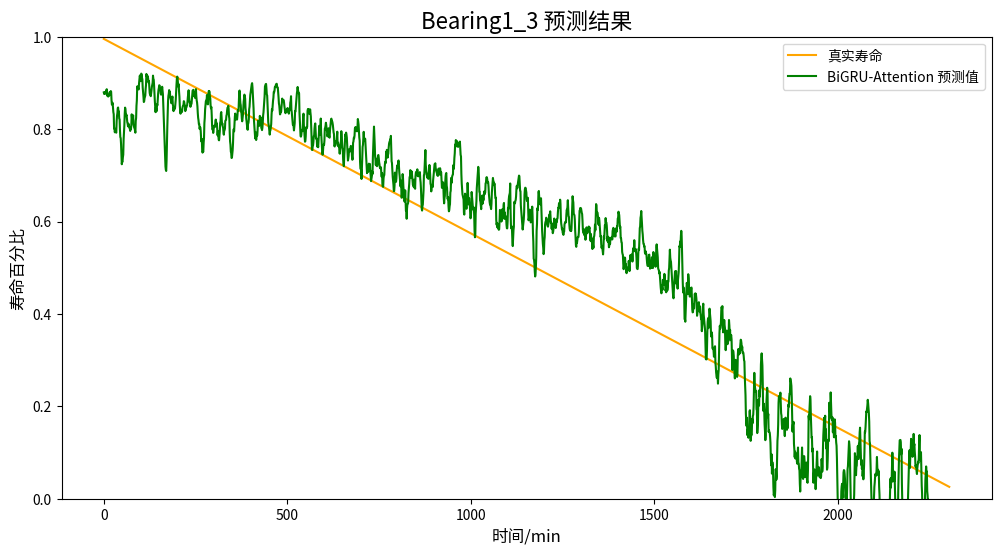

['../相关可视化/bigru__attention_pre']

In [12]:
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 可视化结果
plt.figure(figsize=(12, 6), dpi=100)
plt.plot(test_origin_data, label='真实寿命',color='orange')  # 真实值
plt.plot(test_pre_data, label='BiGRU-Attention 预测值',color='green')  # 预测值

# plt.plot([-1,170],[2.0*0.7,2.0*0.7],c='black',lw=1,ls='--')  # 临界点直线  可自己调整位置
# 设置y轴范围为0到1
plt.ylim(0, 1)

plt.xlabel('时间/min', fontsize=12)
plt.ylabel('寿命百分比', fontsize=12)
plt.title('Bearing1_3 预测结果', fontsize=16)
plt.legend()
plt.show()

# 保存数据
dump(test_origin_data, '../相关可视化/bigru_attention_origin') 
dump(test_pre_data, '../相关可视化/bigru__attention_pre') 

BiGRU-Attetnion test function: Y = 0.0133 + 1.0131 *X.


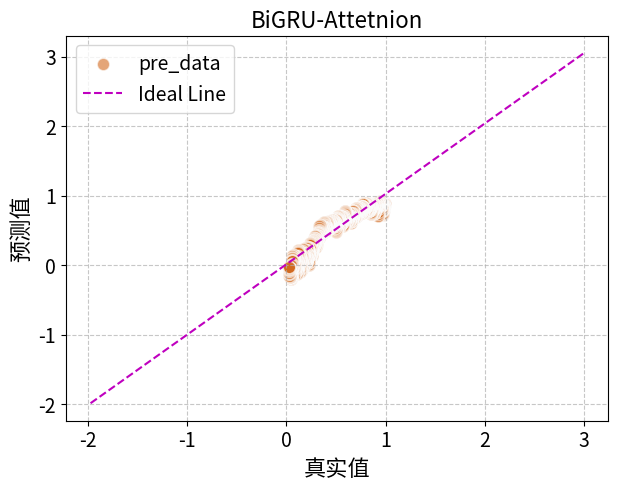

In [13]:
from sklearn.linear_model import LinearRegression

test_y = np.array(test_origin_data).reshape(-1)
pred = test_pre_data
ylow = np.min(test_y) - 2
yhigh = np.max(test_y) + 2
x_center = np.mean(test_y)
y_center = np.mean(pred)
xline_test = np.linspace(ylow, yhigh, 50)
lr_test = LinearRegression()
lr_test.fit(test_y.reshape(-1, 1), pred)
yline_test = lr_test.predict(xline_test.reshape(-1, 1))
test_coef = round(lr_test.coef_[0][0], 4)
test_bias = round(lr_test.intercept_[0], 4)
y_test_func = 'Y = ' + str(test_bias) + ' + ' + str(test_coef) + ' *X'
print(f'BiGRU-Attetnion test function: {y_test_func}.')
plt.figure(figsize=(7, 5))
plt.title('BiGRU-Attetnion',fontsize=16)

# 用透明度和不同颜色增强可视化效果
plt.scatter(test_y, pred, color='chocolate', alpha=0.6, edgecolors='w', s=80, label='pre_data')
plt.plot(xline_test, yline_test, 'm--', label='Ideal Line')

plt.ylabel('预测值', fontsize=16)
plt.xlabel('真实值', fontsize=16)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
# 添加网格线
plt.grid(True, linestyle='--', alpha=0.7)

# 添加图例
plt.legend(fontsize=14)

# 显示图表
plt.show()

In [14]:
import numpy as np
import torch
import time
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from thop import profile

# ==================== 1. 模型预处理（关键！放在最前） ====================
# 解除DataParallel包装 + 统一设备 + eval模式（避免后续所有设备问题）
model = model.module if isinstance(model, torch.nn.DataParallel) else model
model = model.to(device).eval()  # 一次性解决所有设备冲突

# ==================== 2. 回归指标计算 ====================
def calculate_regression_metrics(y_true, y_pred, epsilon=1e-8):
    def to_numpy_1d(x):
        if isinstance(x, list): x = np.array(x)
        elif isinstance(x, torch.Tensor): x = x.detach().cpu().numpy()
        return np.array(x).flatten() if not isinstance(x, np.ndarray) else x.flatten()

    y_true, y_pred = to_numpy_1d(y_true), to_numpy_1d(y_pred)
    mse = mean_squared_error(y_true, y_pred)
    return {
        'MSE': round(mse, 6),
        'MAE': round(mean_absolute_error(y_true, y_pred), 6),
        'RMSE': round(np.sqrt(mse), 6),
        'MAPE(%)': round(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + epsilon))) * 100, 4),
        'R2': round(r2_score(y_true, y_pred), 6)
    }

metrics = calculate_regression_metrics(test_origin_data, test_pre_data)
print("✅ 测试集指标:", metrics)

# ==================== 3. 参数量统计（修复DataParallel重复计数问题） ====================
def count_model_params(model):
    return {
        'total_params': sum(p.numel() for p in model.parameters()),
        'trainable_params': sum(p.numel() for p in model.parameters() if p.requires_grad)
    }

params_info = count_model_params(model)  # 此时model已是纯净原始模型
print(f"✅ 总参数量: {params_info['total_params']:,} ({params_info['total_params']/1e6:.2f} M)")

# ==================== 4. FLOPs计算 ====================
def get_flops_thop(model, input_sample):
    with torch.no_grad():
        flops, _ = profile(model, inputs=(input_sample,), verbose=False)
    return flops

dummy_input = torch.randn(1, 10, 13).to(device)  # PHM2012窗口=10
flops = get_flops_thop(model, dummy_input)
print(f"✅ FLOPs: {flops:,.0f} ({flops/1e6:.2f} MFLOPs)")

# ==================== 5. 推理延迟测量 ====================
x = torch.randn(1, 10, 13).to(device)
for _ in range(50): _ = model(x)  # 预热
start = time.time()
for _ in range(100): _ = model(x)
if device.type == 'cuda': torch.cuda.synchronize()
latency_ms = (time.time() - start) / 100 * 1000
print(f"✅ 单样本推理延迟: {latency_ms:.2f} ms")

✅ 测试集指标: {'MSE': 0.010513, 'MAE': 0.086599, 'RMSE': 0.102534, 'MAPE(%)': 37.0418, 'R2': 0.865947}
✅ 总参数量: 108,609 (0.11 M)
✅ FLOPs: 1,095,936 (1.10 MFLOPs)
✅ 单样本推理延迟: 0.54 ms
